In [1]:
import pandas as pd
import re
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
df_all = pd.read_csv("../data/fused_spectra_all.csv")
df_none = pd.read_csv("../data/fused_xvoo_none.csv")

# def reduce_label(label):
#     label = label.lower().strip()

#     if label in {"xvoo_none", "xvoo_sfo50", "xvoo_sfo100"}:
#         return label

#     match = re.match(r"xvoo_([a-z]+)(\d+)", label)

#     if not match:
#         return label

#     oil_type = match.group(1)
#     percentage = int(match.group(2))

#     if percentage <= 50:
#         return f"xvoo_{oil_type}_leq50"
#     else:
#         return f"xvoo_{oil_type}_gt50"

# df_all["label"] = df_all["label"].apply(reduce_label)
# df_none["target"] = df_none["target"].apply(reduce_label)

df_all["label"] = df_all["label"].str.lower()
df_none["target"] = df_none["target"].str.lower()

df_none = df_none.rename(columns={"target": "label"})

df_combined = pd.concat([df_all, df_none], ignore_index=True)

print("Unique reduced classes:")
print(sorted(df_combined["label"].unique()))

df_combined.to_csv("../data/fused_spectra_reduced.csv", index=False)

print("Saved reduced dataset to ../data/fused_spectra_reduced.csv")

df_combined.head()

Unique reduced classes:
['xvoo_lso10', 'xvoo_lso100', 'xvoo_lso20', 'xvoo_lso30', 'xvoo_lso40', 'xvoo_lso50', 'xvoo_lso60', 'xvoo_lso70', 'xvoo_lso80', 'xvoo_lso90', 'xvoo_none', 'xvoo_oo10', 'xvoo_oo100', 'xvoo_oo20', 'xvoo_oo30', 'xvoo_oo40', 'xvoo_oo50', 'xvoo_oo60', 'xvoo_oo70', 'xvoo_oo80', 'xvoo_oo90', 'xvoo_sfo100', 'xvoo_sfo50']
Saved reduced dataset to ../data/fused_spectra_reduced.csv


,0,1,2,3,4,5,6,7,8,9,...,795,796,797,798,799,800,801,802,803,label
0,0.553666,0.542668,0.539219,0.550110,0.527427,0.528308,0.517648,0.529601,0.538216,0.555890,...,130.0,168.0,63.0,45.0,66.0,0.0,2.0,52.0,104.0,xvoo_lso50
1,0.549612,0.544832,0.551338,0.531563,0.509033,0.525454,0.531417,0.528570,0.532012,0.561593,...,0.0,174.0,92.0,169.0,32.0,31.0,0.0,74.0,91.0,xvoo_lso50
2,0.534978,0.566560,0.547051,0.540911,0.520706,0.544166,0.531983,0.520321,0.544421,0.549850,...,133.0,0.0,59.0,66.0,159.0,76.0,167.0,5.0,48.0,xvoo_lso50
3,0.554111,0.545057,0.541321,0.547764,0.515394,0.528548,0.531013,0.542525,0.528565,0.553415,...,0.0,137.0,5.0,208.0,175.0,74.0,34.0,65.0,94.0,xvoo_lso50
4,0.559351,0.555786,0.544701,0.542401,0.513132,0.533173,0.518915,0.536339,0.541383,0.560227,...,42.0,73.0,67.0,47.0,50.0,0.0,96.0,141.0,96.0,xvoo_lso50


In [3]:
X = df_combined.drop(columns=["label"]).values
y = df_combined["label"].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class SpectraDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = SpectraDataset(X_train, y_train)
test_dataset = SpectraDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP(
    input_dim=X_train.shape[1],
    num_classes=len(label_encoder.classes_)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50

for epoch in range(epochs):
    model.train()
    total_loss = 0
    num_batches = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1
        
    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(batch_y.numpy())


acc = accuracy_score(all_true, all_preds)
print(f"Accuracy: {acc * 100:.2f}%")

print(
    classification_report(
        all_true,
        all_preds,
        target_names=label_encoder.classes_
    )
)

Classes: ['xvoo_lso10' 'xvoo_lso100' 'xvoo_lso20' 'xvoo_lso30' 'xvoo_lso40'
 'xvoo_lso50' 'xvoo_lso60' 'xvoo_lso70' 'xvoo_lso80' 'xvoo_lso90'
 'xvoo_none' 'xvoo_oo10' 'xvoo_oo100' 'xvoo_oo20' 'xvoo_oo30' 'xvoo_oo40'
 'xvoo_oo50' 'xvoo_oo60' 'xvoo_oo70' 'xvoo_oo80' 'xvoo_oo90' 'xvoo_sfo100'
 'xvoo_sfo50']
Epoch 1/50, Loss: 2.1838
Epoch 2/50, Loss: 1.2358
Epoch 3/50, Loss: 0.8477
Epoch 4/50, Loss: 0.6247
Epoch 5/50, Loss: 0.5224
Epoch 6/50, Loss: 0.4035
Epoch 7/50, Loss: 0.3493
Epoch 8/50, Loss: 0.2918
Epoch 9/50, Loss: 0.2673
Epoch 10/50, Loss: 0.2641
Epoch 11/50, Loss: 0.2208
Epoch 12/50, Loss: 0.2608
Epoch 13/50, Loss: 0.1781
Epoch 14/50, Loss: 0.1520
Epoch 15/50, Loss: 0.1573
Epoch 16/50, Loss: 0.1504
Epoch 17/50, Loss: 0.1455
Epoch 18/50, Loss: 0.1288
Epoch 19/50, Loss: 0.1277
Epoch 20/50, Loss: 0.1206
Epoch 21/50, Loss: 0.0772
Epoch 22/50, Loss: 0.0877
Epoch 23/50, Loss: 0.1098
Epoch 24/50, Loss: 0.1044
Epoch 25/50, Loss: 0.1232
Epoch 26/50, Loss: 0.0835
Epoch 27/50, Loss: 0.1043
E

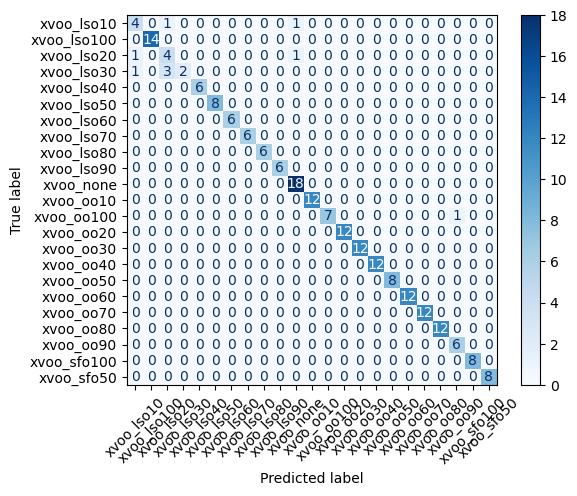

In [4]:
cm = confusion_matrix(all_true, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(xticks_rotation=45, cmap="Blues")
plt.show()